In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Load data (adjust path to your CSV)
df = pd.read_csv('/content/drive/MyDrive/Datasets/PEPSICO_stock_data.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)

# Remove rows with NaT in the index before applying asfreq
df = df[df.index.notna()]

# Ensure data is complete (fill missing dates if needed)
df = df.asfreq('D').fillna(method='ffill')

# Keep only 'Close' price for forecasting
ts = df['Close']

/tmp/ipython-input-37-537914395.py:15: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.asfreq('D').fillna(method='ffill')


/usr/local/lib/python3.11/dist-packages/pandas/plotting/_matplotlib/core.py:975: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


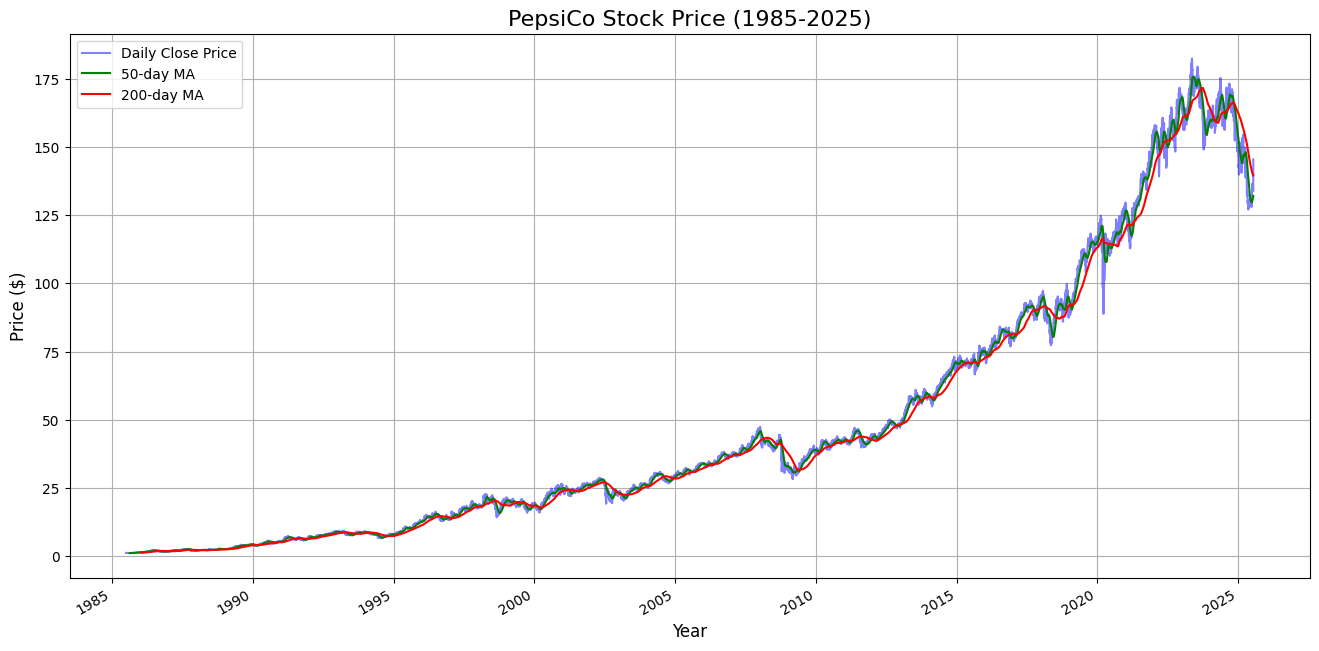

In [ ]:
plt.figure(figsize=(16, 8))

# Plot raw closing prices
plt.plot(ts, label='Daily Close Price', color='blue', alpha=0.5)

# Add 50-day and 200-day moving averages
ts.rolling(50).mean().plot(label='50-day MA', color='green')
ts.rolling(200).mean().plot(label='200-day MA', color='red')

plt.title('PepsiCo Stock Price (1985-2025)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

# Augmented Dickey-Fuller test for stationarity
adf_test = adfuller(ts.dropna())
print(f"ADF Statistic: {adf_test[0]}")
print(f"p-value: {adf_test[1]}")  # If p > 0.05, data is non-stationary

# Apply differencing (if p > 0.05)
ts_diff = ts.diff().dropna()

ADF Statistic: 0.4212916384820844
p-value: 0.982273945866639


In [ ]:
# First difference (usually sufficient)
ts_diff = ts.diff().dropna()

# Check stationarity again
adf_test = adfuller(ts_diff)
print(f"ADF p-value after differencing: {adf_test[1]}")

# If still non-stationary (p > 0.05), take second difference
if adf_test[1] > 0.05:
    ts_diff = ts_diff.diff().dropna()
    print(f"ADF p-value after 2nd difference: {adfuller(ts_diff)[1]}")

ADF p-value after differencing: 0.0


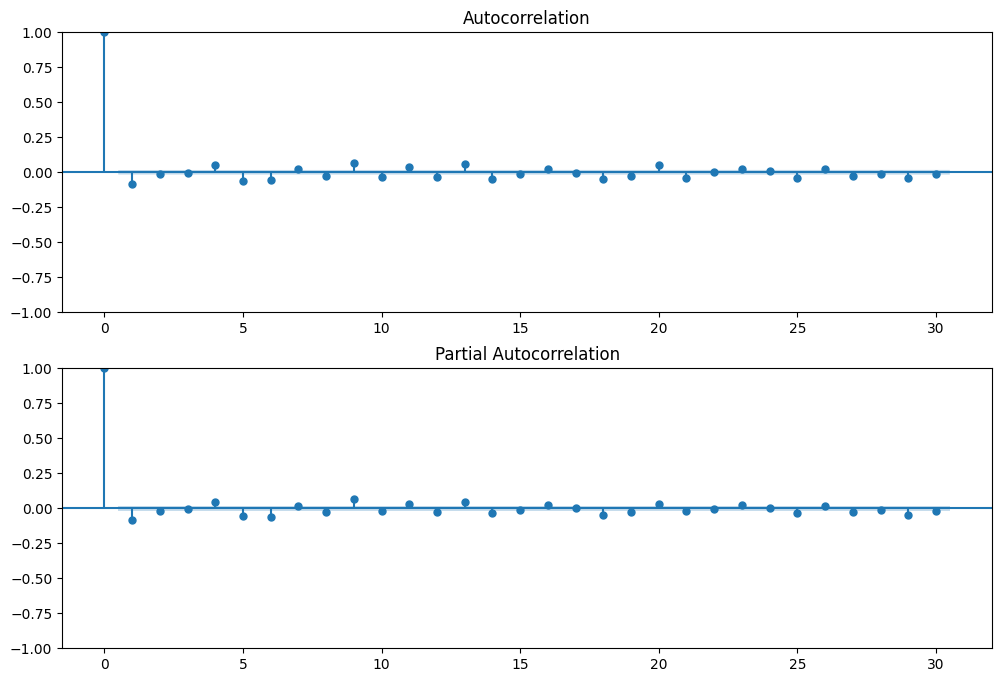

In [42]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(ts_diff, lags=30, ax=ax1)  # Look for cutoff in ACF (MA term, q)
plot_pacf(ts_diff, lags=30, ax=ax2) # Look for cutoff in PACF (AR term, p)
plt.show()

In [43]:
# Example: ARIMA(1,1,1) if ACF/PACF suggest p=1, q=1
model = ARIMA(ts_log, order=(1, 1, 1))  # Using log-transformed data
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                14627
Model:                 ARIMA(1, 1, 1)   Log Likelihood               43428.358
Date:                Fri, 25 Jul 2025   AIC                         -86850.716
Time:                        07:42:54   BIC                         -86827.944
Sample:                    07-01-1985   HQIC                        -86843.151
                         - 07-17-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5066      0.056      9.121      0.000       0.398       0.616
ma.L1         -0.5650      0.054    -10.454      0.000      -0.671      -0.459
sigma2         0.0002   6.72e-07    229.450      0.0

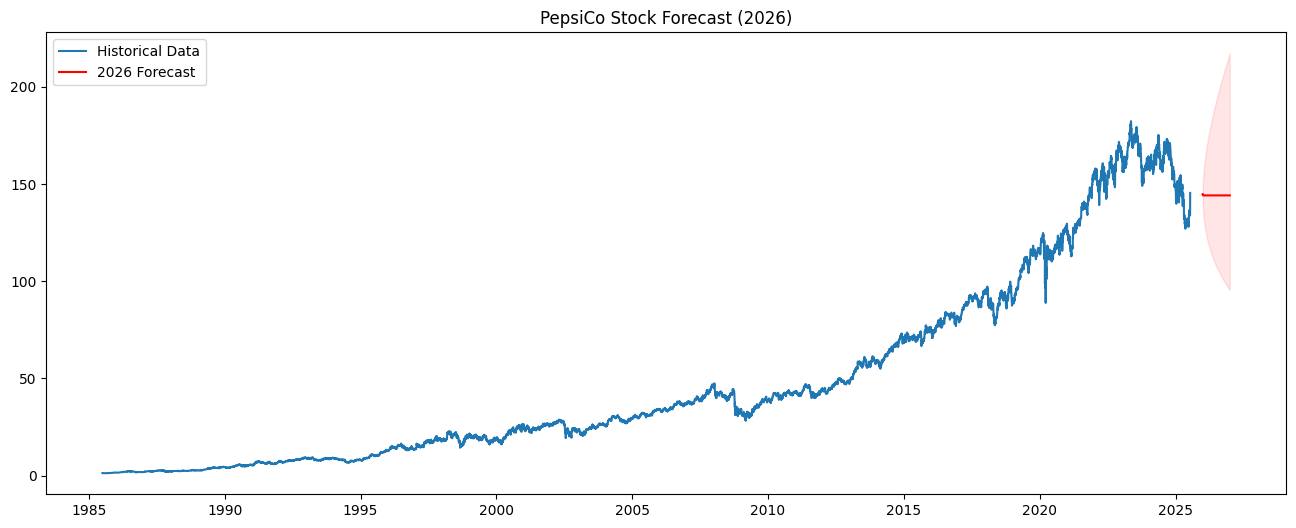

In [44]:
# Forecast 365 days ahead
forecast = model_fit.get_forecast(steps=365)
forecast_values = np.exp(forecast.predicted_mean)  # Reverse log transform
conf_int = np.exp(forecast.conf_int())  # Reverse log for CIs

# Plot results
plt.figure(figsize=(16, 6))
plt.plot(ts, label='Historical Data')
plt.plot(pd.date_range('2025-12-31', periods=366)[1:], forecast_values,
         label='2026 Forecast', color='red')
plt.fill_between(pd.date_range('2025-12-31', periods=366)[1:],
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color='red', alpha=0.1)
plt.title('PepsiCo Stock Forecast (2026)')
plt.legend()
plt.show()